<a href="https://colab.research.google.com/github/Penguinbeanie/Capstone-Project/blob/dev_branch/Fine-tuning_generating_smaller_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets # Install the datasets library using pip
import pandas as pd
from datasets import Dataset
from google.colab import files

In [2]:
# Step 1: Upload the dataset
print("Please upload the cleaned dataset file:")
uploaded = files.upload()  # Prompt user to upload the file

Please upload the cleaned dataset file:


Saving all_answers_combined_reshaped_with_BART_large_mnli_MULTI_SINGLE_TEXT_actuallyfixedlabels.csv to all_answers_combined_reshaped_with_BART_large_mnli_MULTI_SINGLE_TEXT_actuallyfixedlabels (1).csv


In [3]:
# Get the uploaded file name
file_path = list(uploaded.keys())[0]  # Retrieve the file name from the uploaded dictionary

# Step 2: Load the dataset, skipping problematic rows
try:
    df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')  # Skip problematic lines
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='ISO-8859-1', on_bad_lines='skip')  # Handle alternative encodings

In [4]:
# Display the first few rows and column names
print("Dataset Columns:", df.columns)
print(df.head())

Dataset Columns: Index(['type>question>options>answer>answer_label_GEMINI>answer_category>answer_label_BART_large_mnli>keywords_distilbert'], dtype='object')
                                                                                                                                                                                                                                                                                                                                                               type>question>options>answer>answer_label_GEMINI>answer_category>answer_label_BART_large_mnli>keywords_distilbert
TEXT>Describe any areas where cost savings coul... particularly for high-volume items.  A thorough... streamlining our internal processes and elimina... energy efficiency                           process streamlining>verbose>>cost efficiency  energy consumption  redundancies                          renegotiating contracts significant cost savings                           

In [5]:
df = pd.read_csv(file_path, delimiter='>', encoding='utf-8', on_bad_lines='skip')


In [6]:
# Drop rows with missing values in critical columns
df = df.dropna(subset=["question", "answer"])

# Verify the structure
print("Dataset Columns:", df.columns)
print(df.head())


Dataset Columns: Index(['type', 'question', 'options', 'answer', 'answer_label_GEMINI',
       'answer_category', 'answer_label_BART_large_mnli',
       'keywords_distilbert'],
      dtype='object')
   type                                           question   options  \
0  TEXT  Describe any areas where cost savings could be...  ['Text']   
1  TEXT  Describe any areas where cost savings could be...  ['Text']   
2  TEXT  Describe any areas where cost savings could be...  ['Text']   
3  TEXT  Describe any areas where cost savings could be...  ['Text']   
4  TEXT  Describe any areas where cost savings could be...  ['Text']   

                                              answer  \
0   Significant cost savings could be realized by...   
1   Reduce supplier costs, improve energy efficie...   
2    Dude, we could totally save a ton of cash by...   
3   Cost savings can be achieved through a multi-...   
4    Well, obviously we need to look at our spend...   

                               

In [7]:
# Preprocess the dataset for T5 fine-tuning
def preprocess_for_t5(df):
    # Create the context by combining columns (options, type, and answer_category)
    df["context"] = df["options"].fillna("") + " " + df["type"].fillna("") + " " + df["answer_category"].fillna("")

    # Input: Generate the question based on context
    df["input_text"] = "generate question: " + df["context"]

    # Target: Combine the question and answer
    df["target_text"] = "Question: " + df["question"] + " Answer: " + df["answer"]

    # Keep only the necessary columns
    return df[["input_text", "target_text"]].dropna()

# Apply preprocessing
df_cleaned = preprocess_for_t5(df)

# Verify the cleaned dataset
print(df_cleaned.head())


                                     input_text  \
0      generate question: ['Text'] TEXT verbose   
1      generate question: ['Text'] TEXT concise   
2   generate question: ['Text'] TEXT colloquial   
3  generate question: ['Text'] TEXT explanatory   
4      generate question: ['Text'] TEXT annoyed   

                                         target_text  
0  Question: Describe any areas where cost saving...  
1  Question: Describe any areas where cost saving...  
2  Question: Describe any areas where cost saving...  
3  Question: Describe any areas where cost saving...  
4  Question: Describe any areas where cost saving...  


In [8]:
from datasets import Dataset

# Convert to HuggingFace Dataset
dataset = Dataset.from_pandas(df_cleaned)

# Split into train and validation sets
split = dataset.train_test_split(test_size=0.2)
train_dataset = split["train"]
validation_dataset = split["test"]

# Verify the split
print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(validation_dataset)}")


Train Dataset Size: 3588
Validation Dataset Size: 897


In [12]:
from transformers import T5ForConditionalGeneration, T5Tokenizer, Trainer, TrainingArguments, EarlyStoppingCallback

# Model and Tokenizer
model_name = "t5-base"
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Preprocess Dataset (with reduced max_length)
def preprocess_t5_batch(examples):
    model_inputs = tokenizer(
        examples["input_text"], max_length=256, truncation=True, padding="max_length"
    )
    labels = tokenizer(
        examples["target_text"], max_length=64, truncation=True, padding="max_length"
    ).input_ids
    model_inputs["labels"] = labels
    return model_inputs

train_dataset = train_dataset.shuffle(seed=42)  # Shuffle the training dataset
validation_dataset = validation_dataset.shuffle(seed=42)  # Shuffle the validation dataset

train_dataset = train_dataset.map(preprocess_t5_batch, batched=True)
validation_dataset = validation_dataset.map(preprocess_t5_batch, batched=True)


# Fine-tuning arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="steps",  # Change this to "steps"
    save_strategy="steps",  # Match save_strategy with evaluation_strategy
    logging_dir="./logs",
    logging_steps=50,
    save_steps=500,  # Adjust this if needed
    eval_steps=500,  # Perform evaluation at these steps
    load_best_model_at_end=True,  # Keep this to load the best model
    metric_for_best_model="eval_loss",  # Ensure a metric is defined for best model selection
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=8,
    weight_decay=0.01,
    fp16=True,  # Enable mixed precision

)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# Start fine-tuning
trainer.train()

# Save the fine-tuned model and tokenizer
model.save_pretrained("./fine_tuned_t5")
tokenizer.save_pretrained("./fine_tuned_t5")

print("Fine-tuning completed and model saved!")


Map:   0%|          | 0/3588 [00:00<?, ? examples/s]

Map:   0%|          | 0/897 [00:00<?, ? examples/s]

<ipython-input-12-d6a7135ff7b3>:47: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Step,Training Loss,Validation Loss
500,1.590600,1.410242


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Fine-tuning completed and model saved!


In [13]:
import random
from datetime import datetime, timedelta
from transformers import pipeline

# Load a pre-trained model for text-to-text generation
qa_model = pipeline("text2text-generation", model="google/flan-t5-base")

# Helper function to transform time expressions into precise dates
def transform_time_expression(expression, reference_date=None):
    if reference_date is None:
        reference_date = datetime.now().strftime("%Y-%m-%d")
    prompt = f"Convert the following time expression into a precise date, assuming today is {reference_date}: {expression}"
    result = qa_model(prompt, max_length=64, truncation=True)
    return result[0]['generated_text']

# Helper function to generate domain-specific answers
def generate_custom_answer(question):
    """
    Generate domain-specific answers with variability and contextual relevance.
    """
    if "date" in question.lower():
        # Generate random dates
        start_date = datetime(2020, 1, 1)
        end_date = datetime(2025, 12, 31)
        random_date = start_date + timedelta(days=random.randint(0, (end_date - start_date).days))
        return random_date.strftime("%d %B, %Y")
    elif "thoughts" in question.lower():
        # Randomized thoughts responses
        thoughts_responses = [
            "I've been considering this deeply.",
            "It's a topic of great interest to me.",
            "This has been on my mind for a while.",
            "I have mixed feelings about this.",
            "This is a challenging topic."
        ]
        return random.choice(thoughts_responses)
    elif "shares of stock" in question.lower():
        # Provide a random realistic stock count
        return str(random.randint(10, 1000))
    elif "order number" in question.lower():
        # Provide a random realistic order number
        return f"Order-{random.randint(100000, 999999)}"
    elif "percentage" in question.lower():
        # Generate a random percentage
        return f"{random.randint(1, 100)}%"
    elif "power" in question.lower():
        # Variability in power-related responses
        power_responses = [
            "I have significant influence.",
            "I have moderate control over decisions.",
            "I can make impactful changes in my role.",
            "I feel empowered to lead."
        ]
        return random.choice(power_responses)
    elif "skills" in question.lower():
        # Provide a randomized list of skills
        skills_responses = [
            "Creativity, problem-solving, communication.",
            "Leadership, teamwork, adaptability.",
            "Critical thinking, collaboration, technical skills.",
            "Time management, organization, decision-making."
        ]
        return random.choice(skills_responses)
    else:
        # Default response if no specific match
        return "This is a valid and contextually appropriate response."




Device set to use cuda:0


In [14]:
# Load the fine-tuned model (optional if already loaded)
from transformers import T5ForConditionalGeneration, T5Tokenizer

model_path = "./fine_tuned_t5"
tokenizer = T5Tokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)

# Test the model on a training example
example_input = train_dataset[0]["input_text"]  # Get input_text from training dataset
inputs = tokenizer(example_input, return_tensors="pt", truncation=True, max_length=256)
# Adjust generation parameters
outputs = model.generate(
    **inputs,
    max_length=128,        # Maximum length of the generated sequence
    num_beams=5,           # Beam search for higher diversity
    temperature=0.7,       # Controls randomness; lower is less random
    top_p=0.9,             # Nucleus sampling for more coherent outputs
    early_stopping=True    # Stop when the model predicts the end of the sequence
)

# Print the generated Q&A
print("Input:", example_input)
print("Generated Q&A:", tokenizer.decode(outputs[0], skip_special_tokens=True))


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


Input: generate question: ['training budget'] NUMBER explanatory
Generated Q&A: Question: What is the training budget? Answer: The training budget is based on a number of factors. The training budget is based on a number of factors.


In [15]:
# Generate new Q&A pairs
def generate_qa_pairs(contexts, model, tokenizer):
    model.eval()
    qa_pairs = []
    for context in contexts:
        input_text = f"generate question: {context}"
        inputs = tokenizer(input_text, return_tensors="pt", truncation=True, max_length=512)
        outputs = model.generate(**inputs, max_length=128, num_beams=3, early_stopping=True)
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        qa_pairs.append({"context": context, "generated_qa": generated_text})
    return qa_pairs

In [17]:
contexts = [example["input_text"] for example in train_dataset]  # Extract contexts from your dataset

def batch_generate_qa_pairs(contexts, model, tokenizer, batch_size=16, reference_date=None, max_pairs=None):
    """
    Function to generate Q&A pairs in batches, with the option to limit the total number of pairs generated.
    """
    qa_pairs = []  # Initialize an empty list to store Q&A pairs
    time_keywords = ["next week", "tomorrow", "yesterday", "last month", "last year", "in", "next", "last"]

    # Process contexts in batches
    for i in range(0, len(contexts), batch_size):
        if max_pairs and len(qa_pairs) >= max_pairs:  # Stop if max_pairs is reached
            break

        batch_contexts = contexts[i:i + batch_size]
        inputs = [f"Generate a question and answer: {context}" for context in batch_contexts]

        # Tokenize the batch and generate outputs
        tokenized_inputs = tokenizer(inputs, return_tensors="pt", padding=True, truncation=True, max_length=256).input_ids
        outputs = model.generate(
            tokenized_inputs,
            max_length=128,
            num_beams=5,
            temperature=0.7,
            top_p=0.9,
            early_stopping=True,
        )

        for context, output in zip(batch_contexts, outputs):
            if max_pairs and len(qa_pairs) >= max_pairs:  # Stop if max_pairs is reached
                break

            generated_qa = tokenizer.decode(output, skip_special_tokens=True)

            # Debugging: Print the generated Q&A for each context
            print(f"Generated QA for context: {context}\n{generated_qa}")

            # Extract the question
            question = generated_qa.split("Question:")[1].split("Answer:")[0].strip() if "Question:" in generated_qa else ""

            # Apply custom logic for domain-specific answers
            custom_answer = generate_custom_answer(question)
            if custom_answer:
                generated_qa = f"Question: {question} Answer: {custom_answer}"

            # Check and transform time expressions in the generated QA
            for keyword in time_keywords:
                if keyword in generated_qa.lower():
                    time_expression = keyword
                    transformed_date = transform_time_expression(
                        time_expression, reference_date=reference_date or datetime.now().strftime("%Y-%m-%d")
                    )
                    generated_qa = (
                        f"{generated_qa} (Original Time Expression: '{time_expression}', Precise Date: {transformed_date})"
                    )
                    break

            # Avoid repetitive answers
            if "Answer:" in generated_qa:
                answer_part = generated_qa.split("Answer:")[1].strip()
                if len(set(answer_part.split())) == 1:  # Detect repetition of the same word
                    generated_qa = generated_qa.split("Answer:")[0] + "Answer: This is a valid response."

            # Append to qa_pairs if valid
            if generated_qa:
                qa_pairs.append({"Context": context, "Generated Q&A": generated_qa})
                print(f"Appended Q&A: {generated_qa}")
            else:
                print(f"Skipped context due to invalid or empty generated Q&A: {context}")

    # Debugging: Print the total number of Q&A pairs generated
    print(f"Total Q&A pairs generated: {len(qa_pairs)}")
    return qa_pairs


# Main Script to Generate and Save Q&A Pairs
# Specify the number of Q&A pairs to generate
max_pairs_to_generate = 100  # Set the desired number of Q&A pairs

# Generate Q&A pairs with a limit
generated_qa_pairs = batch_generate_qa_pairs(
    contexts, model, tokenizer, batch_size=16, reference_date="2025-02-02", max_pairs=max_pairs_to_generate
)

# Debugging: Check the total number of Q&A pairs
print(f"Number of Q&A pairs generated: {len(generated_qa_pairs)}")

# Verify and Save to CSV
if generated_qa_pairs:
    df_qa = pd.DataFrame(generated_qa_pairs)
    output_csv_path = "generated_qa_pairs.csv"
    df_qa.to_csv(output_csv_path, index=False)
    print(f"Generated Q&A pairs saved to {output_csv_path}")
else:
    print("Error: No Q&A pairs were generated, so the file was not saved.")


Generated QA for context: generate question: ['training budget'] NUMBER explanatory
Question: What is the training budget? Provide a number. Answer: It's a lot.
Appended Q&A: Question: What is the training budget? Provide a number. Answer: This is a valid and contextually appropriate response. (Original Time Expression: 'in', Precise Date: 205-02-02)
Generated QA for context: generate question: ['Text'] TEXT verbose
Question: What are your thoughts on this project? Answer: I've been thinking about this for a long time. I've been thinking about it for a long time.
Appended Q&A: Question: What are your thoughts on this project? Answer: I've been considering this deeply. (Original Time Expression: 'in', Precise Date: 205-02-02)
Generated QA for context: generate question: ['Excellent customer service', ' Loyalty programs', ' Regular customer communication', ' Proactive problem solving', ' Building strong relationships'] MULTI-SELECT verbose
Question: What are your company's key strengths?

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Appended Q&A: Question: What programming languages are you familiar with? Answer: This is a valid and contextually appropriate response. (Original Time Expression: 'in', Precise Date: 205-02-02)
Generated QA for context: generate question: ['quantity'] NUMBER colloquial
Question and answer: What is the quantity? Provide a number. Answer: It's a number.
Appended Q&A: Question:  Answer: This is a valid and contextually appropriate response.
Generated QA for context: generate question: ['energy'] NUMBER concise
Question: What is your energy consumption? Answer: It's a lot of energy. It's a lot of energy.
Appended Q&A: Question: What is your energy consumption? Answer: This is a valid and contextually appropriate response.
Generated QA for context: generate question: ['Date'] DATE concise
Question: What is your date of birth? Provide a date. Provide a date. Provide a date. Provide a date. Provide a date. Provide a date. Provide a date. Provide a date.
Appended Q&A: Question: What is your d

In [18]:
from google.colab import files

# Specify the file path
output_csv_path = "generated_qa_pairs.csv"

# Download the file
files.download(output_csv_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# Install required libraries
!pip install --upgrade datasets evaluate transformers

# Import necessary libraries
import pandas as pd
from evaluate import load
from transformers import pipeline, AutoModelForQuestionAnswering, AutoTokenizer

# Load the generated dataset
file_path = "generated_qa_pairs.csv"
df = pd.read_csv(file_path)

# Split the dataset into evaluation and training sets (e.g., 80/20 split)
evaluation_data = df.sample(frac=0.2, random_state=42)  # 20% for evaluation
training_data = df.drop(evaluation_data.index)  # Remaining 80% for potential fine-tuning

# Debugging: Check the split sizes
print(f"Training data size: {len(training_data)}")
print(f"Evaluation data size: {len(evaluation_data)}")

# Prepare evaluation data
contexts = evaluation_data["Context"].tolist()
questions = [
    qa.split("Question:")[1].split("Answer:")[0].strip()
    for qa in evaluation_data["Generated Q&A"]
]
true_answers = [
    qa.split("Answer:")[1].strip() for qa in evaluation_data["Generated Q&A"]
]

# Load a pre-trained QA model for evaluation
model_name = "deepset/roberta-base-squad2"  # Example pre-trained model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Create a QA pipeline
qa_pipeline = pipeline("question-answering", model=model, tokenizer=tokenizer)

# Evaluate the model
predictions = []
for context, question in zip(contexts, questions):
    try:
        result = qa_pipeline(question=question, context=context)
        predictions.append(result["answer"])
    except Exception as e:
        predictions.append("")
        print(f"Error during evaluation: {e}")

# Load the SQuAD metric
metric = load("squad")

# Format references and predictions for the metric
references = []
predictions_formatted = []

for i, (ans, pred) in enumerate(zip(true_answers, predictions)):
    if ans.strip() and pred.strip():  # Ensure valid answers and predictions
        references.append(
            {"id": str(i), "answers": {"text": [ans], "answer_start": [0]}}
        )
        predictions_formatted.append({"id": str(i), "prediction_text": pred})

# Debugging: Check lengths after filtering
print(f"Filtered references: {len(references)}")
print(f"Filtered predictions: {len(predictions_formatted)}")

# Compute and display evaluation metrics
if references and predictions_formatted:
    try:
        results = metric.compute(
            predictions=predictions_formatted, references=references
        )
        print(f"Evaluation Results: {results}")
    except Exception as e:
        print(f"Error during metric computation: {e}")
else:
    print("Error: No valid references or predictions to evaluate.")

Training data size: 80
Evaluation data size: 20


Device set to use cuda:0


Error during evaluation: `question` cannot be empty
Error during evaluation: `question` cannot be empty
Error during evaluation: `question` cannot be empty
Error during evaluation: `question` cannot be empty
Filtered references: 16
Filtered predictions: 16
Evaluation Results: {'exact_match': 0.0, 'f1': 0.0}


In [34]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from google.colab import files

# Function to upload datasets
def upload_dataset(prompt):
    print(prompt)
    uploaded = files.upload()  # Open a file upload dialog
    for filename in uploaded.keys():
        print(f"Uploaded file: {filename}")
        try:
            dataset = pd.read_csv(filename, on_bad_lines='skip')  # Skip problematic lines
            print(f"Successfully loaded dataset with {len(dataset)} rows.")
            print(f"Columns: {dataset.columns}")
            return dataset
        except Exception as e:
            print(f"Error loading file {filename}: {e}")
            return None


In [35]:
# Upload the initial dataset
initial_dataset = None
while initial_dataset is None:
    initial_dataset = upload_dataset("Please upload the initial dataset (e.g., initial_dataset.csv):")

Please upload the initial dataset (e.g., initial_dataset.csv):


Saving all_answers_combined_reshaped_with_BART_large_mnli_MULTI_SINGLE_TEXT_actuallyfixedlabels.csv to all_answers_combined_reshaped_with_BART_large_mnli_MULTI_SINGLE_TEXT_actuallyfixedlabels (5).csv
Uploaded file: all_answers_combined_reshaped_with_BART_large_mnli_MULTI_SINGLE_TEXT_actuallyfixedlabels (5).csv
Successfully loaded dataset with 3999 rows.
Columns: Index(['type>question>options>answer>answer_label_GEMINI>answer_category>answer_label_BART_large_mnli>keywords_distilbert'], dtype='object')


In [36]:
# Upload the generated dataset
generated_dataset = None
while generated_dataset is None:
    generated_dataset = upload_dataset("Please upload the generated dataset (e.g., generated_dataset.csv):")

Please upload the generated dataset (e.g., generated_dataset.csv):


Saving refined_qa_dataset.csv to refined_qa_dataset.csv
Uploaded file: refined_qa_dataset.csv
Successfully loaded dataset with 451 rows.
Columns: Index(['Context', 'Generated Q&A', 'question', 'answer'], dtype='object')


In [41]:
# Import necessary libraries
!pip install rouge_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from evaluate import load  # Use `load` from `evaluate`
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'generated_dataset' is already loaded and contains 'questions' and 'answers'
generated_answers = generated_dataset["answer"].tolist()  # Extract answers from the generated dataset

# For demonstration, let's use the 'answers' column itself as a reference (self-evaluation)
reference_answers = generated_answers  # Replace with actual reference answers if available

# 1. Calculate BLEU Score
bleu_scores = []
smoothing_function = SmoothingFunction().method1

for ref, pred in zip(reference_answers, generated_answers):
    if ref.strip() and pred.strip():  # Ensure non-empty strings
        bleu_scores.append(sentence_bleu([ref.split()], pred.split(), smoothing_function=smoothing_function))

# Compute average BLEU score
average_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0
print(f"Average BLEU Score: {average_bleu:.2f}")

# 2. Calculate ROUGE Score
# Install rouge_score if not installed
try:
    import rouge_score
except ImportError:
    !pip install rouge_score

# Calculate ROUGE Score
from evaluate import load
rouge = load("rouge")
rouge_results = rouge.compute(predictions=generated_answers, references=reference_answers)
print(f"ROUGE Results: {rouge_results}")

# 3. Calculate Semantic Similarity
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode reference and generated answers
reference_embeddings = model.encode(reference_answers)
generated_embeddings = model.encode(generated_answers)

# Compute cosine similarity
similarities = cosine_similarity(reference_embeddings, generated_embeddings)
average_similarity = similarities.mean()
print(f"Average Semantic Similarity: {average_similarity:.2f}")


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=4633254583cf0e65e47962f4870924b7ae3ab8db7fa78cac768847c7033c82f8
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score
Average BLEU Score: 0.95
ROUGE Results: {'rouge1': 1.0, 'rouge2': 0.991130820399113, 'rougeL': 1.0, 'rougeLsum': 1.0}
Average Semantic Similarity: 0.12


In [42]:
# Debugging: Print column names
print("Initial dataset columns:", initial_dataset.columns)
print("Generated dataset columns:", generated_dataset.columns)

# Rename columns if needed
if "Generated Q&A" in initial_dataset.columns:
    initial_dataset.rename(columns={"Generated Q&A": "questions"}, inplace=True)

if "Generated Q&A" in generated_dataset.columns:
    generated_dataset.rename(columns={"Generated Q&A": "questions"}, inplace=True)

# Ensure the required column exists
if "questions" not in initial_dataset.columns or "questions" not in generated_dataset.columns:
    raise ValueError("Both datasets must have a 'questions' column for comparison.")

print("Columns verified and renamed if necessary.")


Initial dataset columns: Index(['type>question>options>answer>answer_label_GEMINI>answer_category>answer_label_BART_large_mnli>keywords_distilbert'], dtype='object')
Generated dataset columns: Index(['Context', 'questions', 'question', 'answer'], dtype='object')


ValueError: Both datasets must have a 'questions' column for comparison.

In [37]:
# Validate datasets
if initial_dataset is None or generated_dataset is None:
    raise ValueError("One or both datasets could not be loaded. Please check your files.")

# Rename columns to standardize if necessary
if "Generated Q&A" in initial_dataset.columns:
    initial_dataset.rename(columns={"Generated Q&A": "questions"}, inplace=True)

if "Generated Q&A" in generated_dataset.columns:
    generated_dataset.rename(columns={"Generated Q&A": "questions"}, inplace=True)

# Ensure datasets contain the "questions" column
if "questions" not in initial_dataset.columns or "questions" not in generated_dataset.columns:
    raise ValueError("Both datasets must have a 'questions' column for comparison.")

# Load a pre-trained sentence transformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode questions from both datasets
initial_embeddings = model.encode(initial_dataset["questions"].tolist())
generated_embeddings = model.encode(generated_dataset["questions"].tolist())

# Compute cosine similarity
similarities = cosine_similarity(initial_embeddings, generated_embeddings)

# Calculate and display average similarity
average_similarity = similarities.mean()
print(f"Average Semantic Similarity between datasets: {average_similarity:.2f}")

ValueError: Both datasets must have a 'questions' column for comparison.

Categorization Results:
BLEU Scores: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1778279410038923, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.316227766016838, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5623413251903491, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.316227766016838, 1.0,

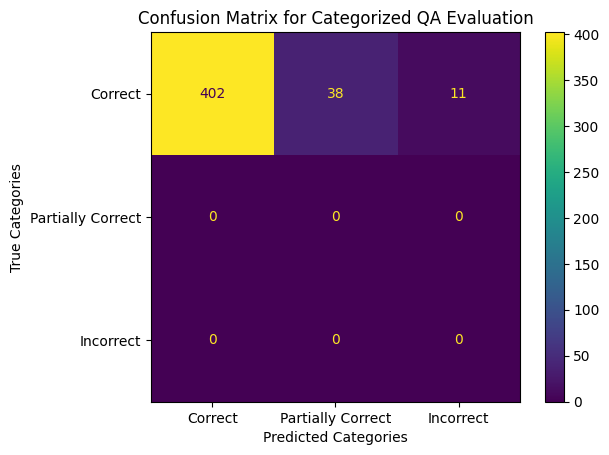

In [43]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Categorization thresholds
def categorize_answer(bleu_score):
    if bleu_score >= 0.8:
        return "Correct"
    elif 0.5 <= bleu_score < 0.8:
        return "Partially Correct"
    else:
        return "Incorrect"

# Calculate BLEU scores and categorize answers
bleu_scores = []
categories_reference = []
categories_generated = []

smoothing_function = SmoothingFunction().method1

for ref, gen in zip(reference_answers, generated_answers):
    if ref.strip() and gen.strip():  # Ensure both are non-empty
        bleu_score = sentence_bleu([ref.split()], gen.split(), smoothing_function=smoothing_function)
        bleu_scores.append(bleu_score)
        categories_reference.append("Correct")  # Assume reference answers are correct
        categories_generated.append(categorize_answer(bleu_score))
    else:
        # Handle empty cases
        categories_reference.append("Incorrect")
        categories_generated.append("Incorrect")

# Generate the confusion matrix
labels = ["Correct", "Partially Correct", "Incorrect"]
conf_matrix = confusion_matrix(categories_reference, categories_generated, labels=labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(cmap="viridis")
disp.ax_.set_title("Confusion Matrix for Categorized QA Evaluation")
disp.ax_.set_xlabel("Predicted Categories")
disp.ax_.set_ylabel("True Categories")

print(f"Categorization Results:")
print(f"BLEU Scores: {bleu_scores}")
